In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [2]:
import pandas as pd

TEXTUAL_EMBEDDINGS_PATH = '../../../../data/textual_features/'

text_emb_128 = TEXTUAL_EMBEDDINGS_PATH + 'textual_embeddings_128.parquet'

df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216


(2950135, 260)


In [3]:
X = df.drop(columns=["is_reference_valid", "article_id", "ref_id", "vector_text_article", "vector_text_ref"], errors="ignore").copy()
y = df["is_reference_valid"].copy()

split_series = X["split"].astype(str).str.lower()
max_rows = len(X)  # Default to using all rows if the dataset is small
random_state = 42

train_idx = X.index[split_series == "train"]
test_idx = X.index[split_series == "test"]
val_idx = X.index[split_series.isin(["validation", "val"])]

# Random sampling avoids taking a contiguous block that may contain a single class.
train_idx = train_idx.to_series().sample(n=min(max_rows, len(train_idx)), random_state=random_state).index
test_idx = test_idx.to_series().sample(n=min(max_rows, len(test_idx)), random_state=random_state).index
val_idx = val_idx.to_series().sample(n=min(max_rows, len(val_idx)), random_state=random_state).index

X_train = X.loc[train_idx].drop(columns=["split"], errors="ignore")
y_train = y.loc[train_idx]
X_test = X.loc[test_idx].drop(columns=["split"], errors="ignore")
y_test = y.loc[test_idx]
X_val = X.loc[val_idx].drop(columns=["split"], errors="ignore")
y_val = y.loc[val_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print("Feature rows:", len(X))
print("Global label distribution:")
print(y.value_counts(normalize=True))
print("\nSplit sizes:", {"train": len(X_train), "test": len(X_test), "val": len(X_val)})
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

del df, X, y, split_series, X_train, X_test, X_val

Feature rows: 2950135
Global label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64

Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}

Train label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64


In [4]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [8]:
from sklearn.model_selection import PredefinedSplit, GridSearchCV
import numpy as np

# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 

def downsample_indices(indices, n_samples):
    if len(indices) > n_samples:
        return np.random.choice(indices, n_samples, replace=False)
    return indices

# Sampling for tuning
train_tuning_idx = downsample_indices(np.arange(len(X_train_scaled)), min(len(X_train_scaled), int(max_tuning_samples * 0.8)))
val_tuning_idx = downsample_indices(np.arange(len(X_val_scaled)), min(len(X_val_scaled), int(max_tuning_samples * 0.2)))

X_train_val_subset = np.vstack((X_train_scaled[train_tuning_idx], X_val_scaled[val_tuning_idx]))
y_train_val_subset = np.concatenate((y_train.iloc[train_tuning_idx], y_val.iloc[val_tuning_idx]))

# Create split indices: -1 for train, 0 for validation
split_index = np.concatenate([
    -1 * np.ones(len(train_tuning_idx)),
    0 * np.ones(len(val_tuning_idx))
])

ps = PredefinedSplit(test_fold=split_index)

# Hyperparameter tuning with GridSearchCV (Subset for speed and RAM)
param_grid = {
    'n_neighbors': range(5,16), # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

print(f"Starting tuning on {len(X_train_val_subset)} samples...")
grid_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid,
    cv=ps,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_val_subset, y_train_val_subset)

print("\nBest parameters found:")
print(grid_search.best_params_)

# Final training on the full dataset with the best parameters
print("\nFinal training on the full dataset...")
model = grid_search.best_estimator_
model.fit(X_train_scaled, y_train)

print(f"\nOptimal model ready: {model}")

Starting tuning on 50000 samples...
Fitting 1 folds for each of 44 candidates, totalling 44 fits

Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 14, 'weights': 'uniform'}

Final training on the full dataset...

Optimal model ready: KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=14)


In [6]:
import sys
import os
from pathlib import Path

from utils.textual_utils.registry.model_saver import LocalModelRegistry

tmp_path = Path("/tmp/model_registry")
registry = LocalModelRegistry(registry_base_path=str(tmp_path))

p = globals().get("best_params", {})
m = globals().get("best_model", model)

n_neighbors = p.get("n_neighbors", "default")
metric = p.get("metric", "default")

model_name_to_save = f"knn_n{n_neighbors}_{metric}"

run_dir = registry.save_experiment(
    model_name=model_name_to_save,
    model=m,
    params=p,
    metrics={
        "scoring": "f1_weighted",
        "max_tuning_samples": int(globals().get("max_tuning_samples", 0)),
    },
    dataset_info={
        "df_name": globals().get("df_name", "unknown")
    }
)

print(f"✅ KNN salvato con successo in: {run_dir}")

✅ Artefatto modello salvato con successo in: /tmp/model_registry/knn_ndefault_default/20260425_000210_cfea3cec
✅ KNN salvato con successo in: /tmp/model_registry/knn_ndefault_default/20260425_000210_cfea3cec


Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 14, 'weights': 'uniform'}
              precision    recall  f1-score   support

           0     0.7103    0.7463    0.7278      2940
           1     0.7437    0.7075    0.7252      3060

    accuracy                         0.7265      6000
   macro avg     0.7270    0.7269    0.7265      6000
weighted avg     0.7273    0.7265    0.7265      6000



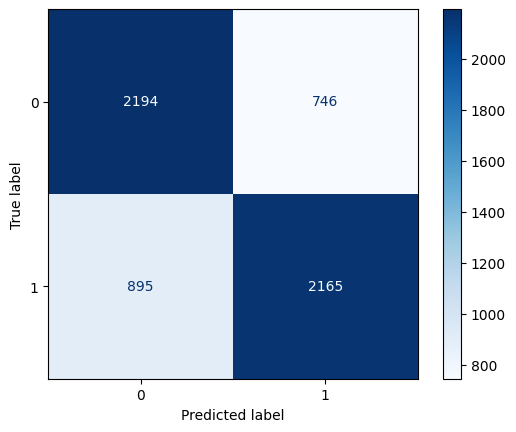

In [9]:
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

y_pred = best_model.predict(X_test_scaled[:6000])
print(classification_report(y_test[:6000], y_pred, digits=4))


cm = confusion_matrix(y_test[:6000], y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues")